In [1]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
print(path)

100%|██████████| 8.89M/8.89M [00:00<00:00, 86.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2


In [2]:
import os
import pandas as pd

path="/root/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2"

print(os.listdir(path))


['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


In [3]:
movies = pd.read_csv(path + "/tmdb_5000_movies.csv")
credits = pd.read_csv(path + "/tmdb_5000_credits.csv")

print(movies.head())
print(movies.shape)


      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [4]:
movies.info()

movies.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [5]:
movies = movies[['title','budget','revenue','vote_average','vote_count',
                 'popularity','release_date','genres','runtime']]

movies.dropna(inplace=True)

movies.head()

,title,budget,revenue,vote_average,vote_count,popularity,release_date,genres,runtime
0,Avatar,237000000,2787965087,7.2,11800,150.437577,2009-12-10,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",162.0
1,Pirates of the Caribbean: At World's End,300000000,961000000,6.9,4500,139.082615,2007-05-19,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",169.0
2,Spectre,245000000,880674609,6.3,4466,107.376788,2015-10-26,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",148.0
3,The Dark Knight Rises,250000000,1084939099,7.6,9106,112.312950,2012-07-16,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",165.0
4,John Carter,260000000,284139100,6.1,2124,43.926995,2012-03-07,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",132.0


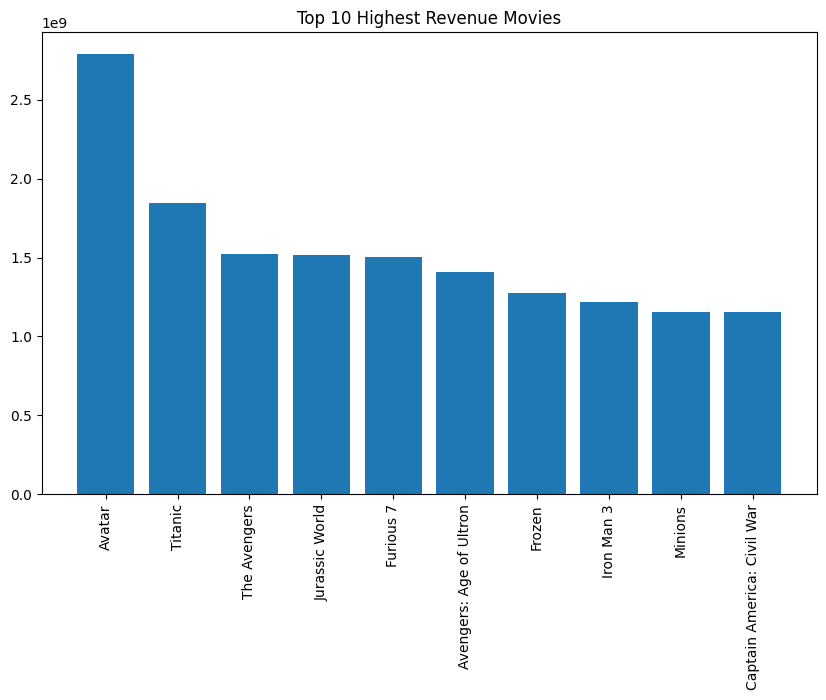

In [6]:
import matplotlib.pyplot as plt

top10 = movies.sort_values('revenue',ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['title'],top10['revenue'])
plt.xticks(rotation=90)
plt.title("Top 10 Highest Revenue Movies")
plt.show()

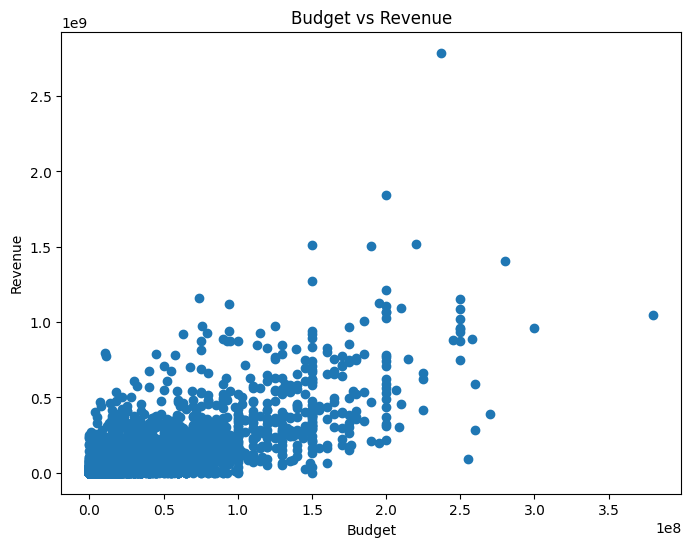

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(movies['budget'],movies['revenue'])
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue")
plt.show()

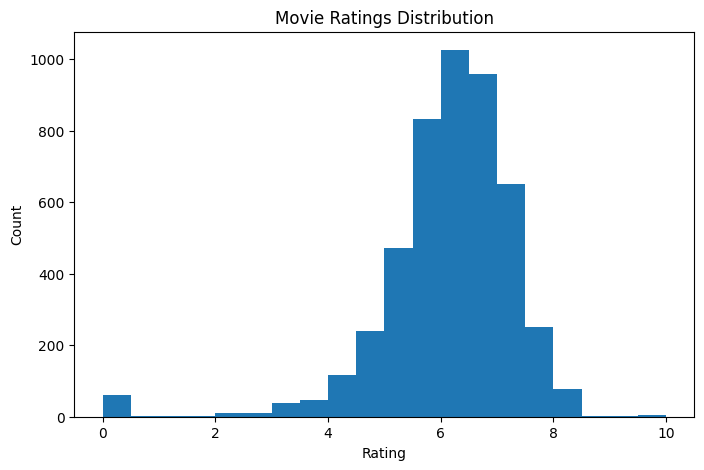

In [8]:
plt.figure(figsize=(8,5))
plt.hist(movies['vote_average'],bins=20)
plt.title("Movie Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = movies[['budget','vote_average','vote_count','popularity','runtime']]
y = movies['revenue']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

prediction = model.predict(X_test)

In [12]:
from sklearn.metrics import r2_score

print("R2 Score:",r2_score(y_test,prediction))

R2 Score: 0.7683904039612219


In [13]:
sample = [[150000000,8.2,9000,120,140]]

pred = model.predict(sample)

print("Predicted Revenue =",pred[0])

Predicted Revenue = 874782544.0933117


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2"

movies = pd.read_csv(path + "/tmdb_5000_movies.csv")
credits = pd.read_csv(path + "/tmdb_5000_credits.csv")

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


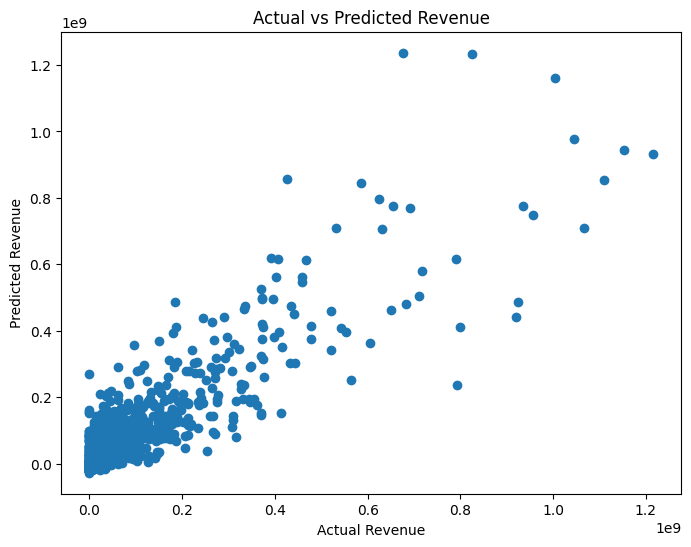

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()